# 신용카드 이상감지 모델을 만들기 위한 데이터

## 목표: 피쳐 엔지니어링 연습

LMS 가이드:
1. 사기거래 여부를 예측하는 데 불필요한 컬럼을 제거합니다.
2. 최소 2개 이상의 새로운 피처(변수)를 생성해봅시다. [힌트] 구매 금액, 시간 등의 변수를 이용할 수 있습니다.

강의의 범위를 벗어나는 개념이 필요할 수 있으니, 인터넷 검색도 적극 활용해보세요.

3. 데이터의 위도/경도 정보를 활용해볼 수 있을까요?
4. 통계적 관점으로 접근하여 유용한 변수를 만들어낼 수 있을까요?

## 데이터 파악

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
cc_df = pd.read_csv('data/fraud.csv')

In [3]:
pd.set_option('display.max_columns', 50)

In [4]:
cc_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [5]:
cc_df.shape

(491134, 22)

## 결측치 확인
IQR(Interquartile Range) 방식

In [6]:
cc_df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## Feature Engineering (변수 상관관계 분석)

### 변수 전략 
1. 제거할 칼럼: first, last, street, zip
2. 제거 보류: gender, state, city_pop
3. 변환할 칼럼: dob -> age, amt -> amt_log, trans_date_trans_time --> hour, day (필요한 파생변수: 거리 변수, 나이 변수)

In [ ]:
cc_df['is_fraud'].value_counts()

is_fraud
0    489890
1      1244
Name: count, dtype: int64

In [96]:
# =================================================================
# INSIGHT: 
# -----------------------------------------------------------------
# 사기 건수: 1,244건 (is_fraud에서 1인 경우): 1244/489890 로 99.75% : 0.25%
# =================================================================

In [33]:
cc_df.nunique()

trans_date_trans_time    488474
cc_num                      124
merchant                    693
category                     14
amt                       36446
first                        92
last                        102
gender                        2
street                      124
city                        121
state                        44
zip                         124
lat                         124
long                        124
city_pop                    122
job                         110
dob                         123
trans_num                491134
unix_time                488477
merch_lat                484503
merch_long               487445
is_fraud                      2
amt_log                   36446
dtype: int64

### 1. 나이(Age) 생성 (2026년 기준) - 파생변수 활용

In [58]:
cc_df['age'] = 2026 - pd.to_datetime(cc_df['dob']).dt.year
cc_df[cc_df['is_fraud'] == 1]['age'].value_counts()


age
54    93
42    84
29    82
52    64
27    58
31    57
41    57
39    54
49    51
51    50
38    44
46    44
36    43
50    37
33    36
53    34
48    34
28    33
35    31
30    31
37    30
55    25
44    24
45    23
32    22
56    22
22    21
43    15
40    14
26    14
23    10
47     4
34     3
Name: count, dtype: int64

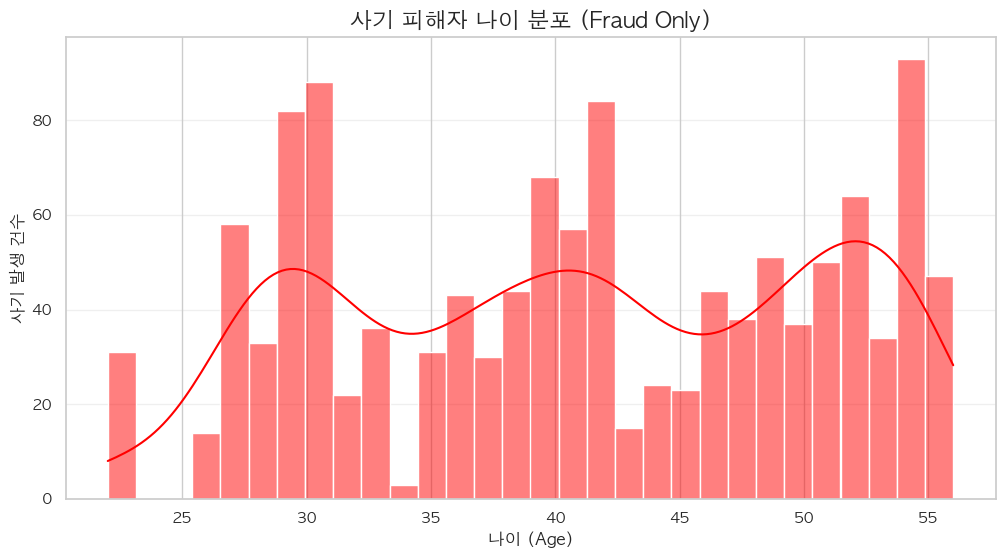

In [60]:
plt.figure(figsize=(12, 6))

# 사기 거래(is_fraud == 1) 데이터만 추출
fraud_df = cc_df[cc_df['is_fraud'] == 1]

# 나이별 분포도 그리기
sns.histplot(fraud_df['age'], kde=True, color='red', bins=30)

plt.title('사기 피해자 나이 분포 (Fraud Only)', fontsize=16)
plt.xlabel('나이 (Age)')
plt.ylabel('사기 발생 건수')
plt.grid(axis='y', alpha=0.3)
plt.show()

나이별 분포 그래프: 20대부터 50대까지 사기 피해가 꽤 고르게 퍼져 있다. 
수치(상관계수)로 증명하자

In [62]:
cc_df[['age', 'is_fraud']].corr()

,age,is_fraud
age,1.000000,-0.004231
is_fraud,-0.004231,1.000000


In [95]:
# =================================================================
# INSIGHT: 
# -----------------------------------------------------------------
# 그래프에서 직관적으로 판단한 것과 다르지 않게 상관관계가 낮게 나왔다.
# =================================================================

### 2. 거리(사용자 주소와 결제가 이루어진 장소 간)의 거리 - 상관관계 탐색

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

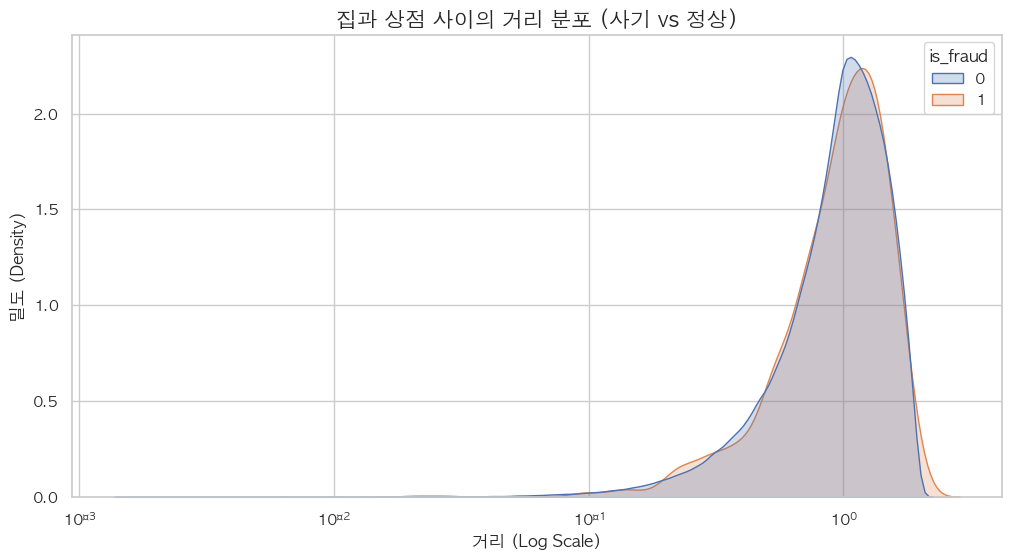

In [80]:
# 파생변수 '거리'(distance) 계산 (단순 차이값의 합으로 우선 생성)
cc_df['dist_lat'] = abs(cc_df['lat'] - cc_df['merch_lat'])
cc_df['dist_long'] = abs(cc_df['long'] - cc_df['merch_long'])
cc_df['distance'] = cc_df['dist_lat'] + cc_df['dist_long']



# 거리 분포 비교 시각화

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))

# 맥 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 사기 거래와 정상 거래의 거리 분포 비교
# log_scale=True를 주면 거리의 미세한 차이를 더 잘 볼 수 있다.
sns.kdeplot(data=cc_df, x='distance', hue='is_fraud', fill=True, common_norm=False, log_scale=True)

plt.title('집과 상점 사이의 거리 분포 (사기 vs 정상)', fontsize=15)
plt.xlabel('거리 (Log Scale)')
plt.ylabel('밀도 (Density)')
plt.show()


In [81]:
cc_df[['distance', 'is_fraud']].corr()

,distance,is_fraud
distance,1.000000,0.000921
is_fraud,0.000921,1.000000


In [93]:
# =================================================================
# INSIGHT: 
# -----------------------------------------------------------------
# 위도/경도를 활용해 생성한 distance 변수를 KDE 분포로 확인한 결과, 
# 정상과 사기 거래의 분포가 매우 유사하여 개별 거래의 거리는 사기 판단의 결정적 요인이 아님을 밝혀냄.
# =================================================================

### 3. 결제 Category 상관관계

In [36]:
cc_df['category'].value_counts()

category
shopping_pos      48345
gas_transport     46029
home              43340
grocery_pos       42722
kids_pets         40295
shopping_net      39179
food_dining       35980
personal_care     35513
entertainment     33619
misc_pos          32411
health_fitness    31415
misc_net          25179
grocery_net       24486
travel            12621
Name: count, dtype: int64

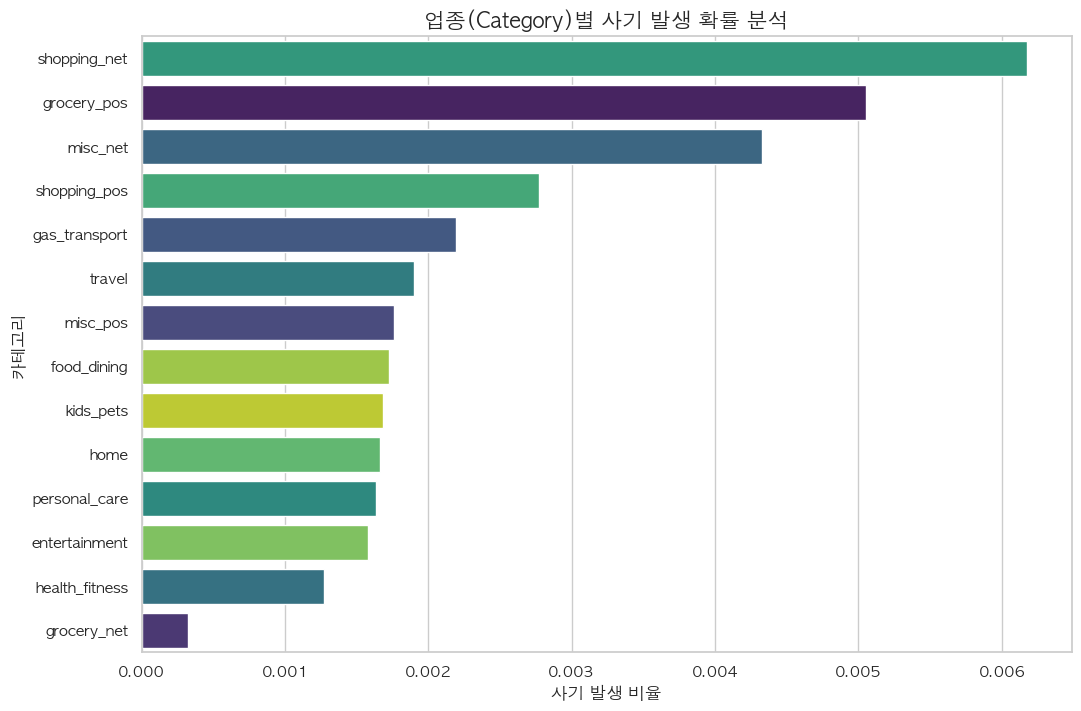

In [ ]:
# 업종별 사기 발생률 계산 (간단 명료 버전)
plt.figure(figsize=(12, 8))

# 사기 발생 확률이 높은 순으로 정렬하여 시각화
cat_order = cc_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).index

sns.barplot(data=cc_df, y='category', x='is_fraud', order=cat_order, errorbar=None, palette='viridis', hue='category', legend=False)

plt.title('업종(Category)별 사기 발생 확률 분석', fontsize=15)
plt.xlabel('사기 발생 비율')
plt.ylabel('카테고리')
plt.show()

In [97]:
# =================================================================
# INSIGHT: 물리적 거리보다  결제 채널(온라인/오프라인)이 사기 판단에 더 유의미한 변수임을 확인
# -----------------------------------------------------------------
# 특히 오프라인(pos) 거래보다 익명성이 보장되는 온라인(net) 거래에서 사기 발생 확률이 상대적으로 높게 나타나므로, 
# 온라인 카테고리에 대한 가중치 부여가 필요하다.
# =================================================================


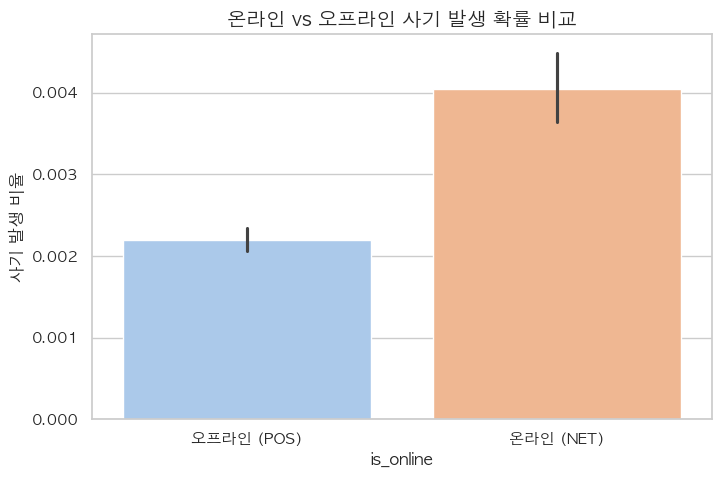

is_online
0    0.002200
1    0.004041
Name: is_fraud, dtype: float64


In [98]:
# 1. 온라인(NET) vs 오프라인(POS) 구분 파생 변수 생성
# category 이름에 'net'이 있으면 1(온라인), 없으면 0(오프라인)으로 할당
cc_df['is_online'] = cc_df['category'].apply(lambda x: 1 if '_net' in x else 0)

# 2. 분석 인사이트 시각화 (온라인 여부에 따른 사기율 비교)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=cc_df, x='is_online', y='is_fraud', hue='is_online', palette='pastel', legend=False)

plt.title('온라인 vs 오프라인 사기 발생 확률 비교', fontsize=14)
plt.xticks([0, 1], ['오프라인 (POS)', '온라인 (NET)'])
plt.ylabel('사기 발생 비율')
plt.show()

# 결과 수치 확인
print(cc_df.groupby('is_online')['is_fraud'].mean())

### 4. 시간 데이터 변환 및 분석

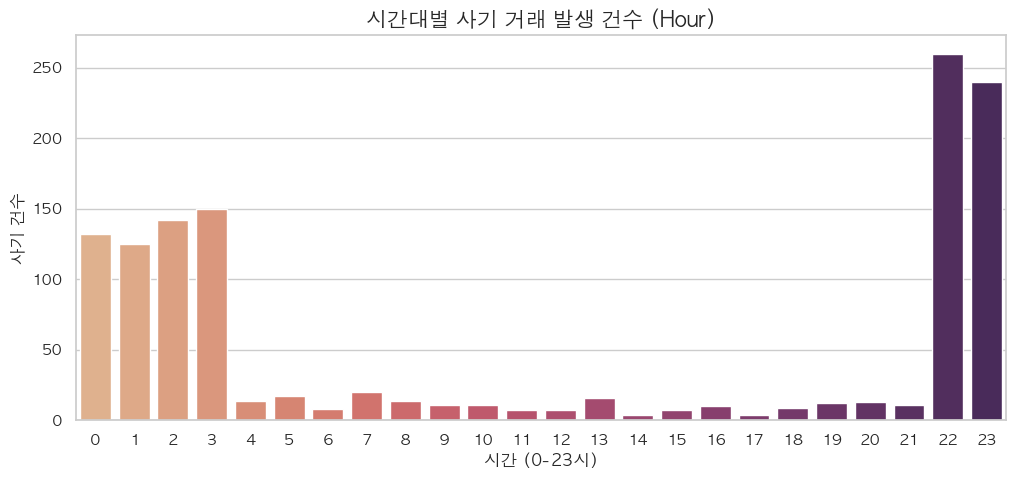

In [90]:
# 데이터 타입 변환
cc_df['transaction_time'] = pd.to_datetime(cc_df['trans_date_trans_time'])

# 시간(Hour)과 요일(Day) 추출 (0=월, 6=일)
cc_df['hour'] = cc_df['transaction_time'].dt.hour
cc_df['day'] = cc_df['transaction_time'].dt.dayofweek

# [시각화] 시간대별 사기 발생 건수
plt.figure(figsize=(12, 5))
sns.countplot(data=cc_df[cc_df['is_fraud'] == 1], x='hour', palette='flare', hue='hour', legend=False)
plt.title('시간대별 사기 거래 발생 건수 (Hour)', fontsize=15)
plt.xlabel('시간 (0-23시)')
plt.ylabel('사기 건수')
plt.show()

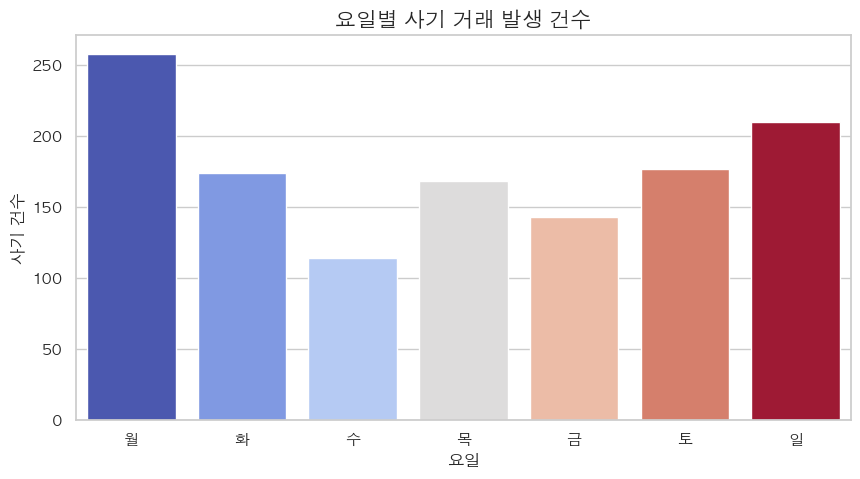

In [91]:
# 요일 이름 매핑 (시각화용)
day_labels = ['월', '화', '수', '목', '금', '토', '일']

plt.figure(figsize=(10, 5))
# 사기 거래(is_fraud == 1) 데이터만 필터링하여 요일별 건수 시각화
sns.countplot(data=cc_df[cc_df['is_fraud'] == 1], x='day', hue='day', palette='coolwarm', legend=False)

plt.xticks(ticks=range(7), labels=day_labels)
plt.title('요일별 사기 거래 발생 건수', fontsize=15)
plt.xlabel('요일')
plt.ylabel('사기 건수')
plt.show()

## 이상치 확인

In [20]:
# 1. 수치형 컬럼만 선택
numeric_df = cc_df.select_dtypes(include=['number'])

# 2. Q1, Q3 계산 및 IQR 구하기
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# 3. 이상치 경계 설정 (보통 1.5배를 사용)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. 각 컬럼별로 이상치가 몇 개씩 있는지 한 방에 확인
outliers_count = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).sum()

print("--- 컬럼별 이상치 개수 ---")
print(outliers_count[outliers_count > 0]) # 이상치가 있는 컬럼만 출력

--- 컬럼별 이상치 개수 ---
cc_num        38686
amt           34800
long           8032
city_pop      85372
merch_long     7087
is_fraud       1244
dtype: int64


### 결제 금액의 이상치 로그 변환

Text(0, 0.5, 'Frequency')

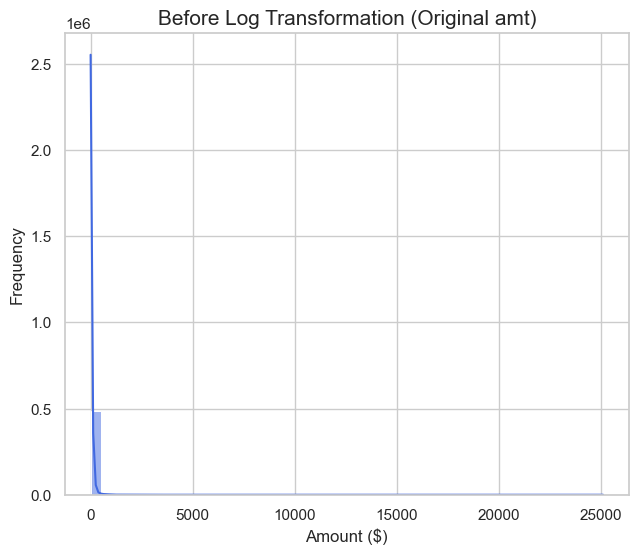

In [24]:
# 이상치 갯수가 많은 Amount의 분포도를 그려보고, 로그변환을 시도 비교해본다.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화를 위한 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 2. 로그 변환 전 (Original Amount)
plt.subplot(1, 2, 1)
sns.histplot(cc_df['amt'], kde=True, color='royalblue', bins=50)
plt.title('Before Log Transformation (Original amt)', fontsize=15)
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 0. 맥(macOS) 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='AppleGothic')

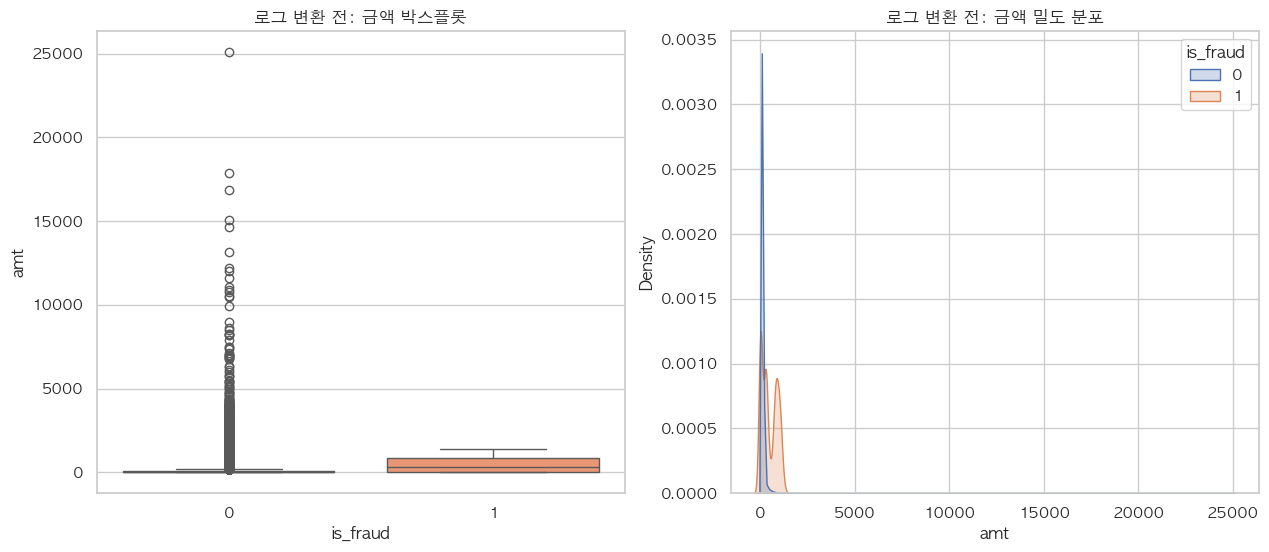

In [30]:
# --- 1단계: 로그 변환 전의 박스플롯과 KDE ---
plt.figure(figsize=(15, 6))

# 왼쪽: 박스플롯
plt.subplot(1, 2, 1)
sns.boxplot(data=cc_df, x='is_fraud', y='amt', hue='is_fraud', palette='Set2', legend=False)
plt.title('로그 변환 전: 금액 박스플롯')

# 오른쪽: KDE
plt.subplot(1, 2, 2)
sns.kdeplot(data=cc_df, x='amt', hue='is_fraud', fill=True, common_norm=False)
plt.title('로그 변환 전: 금액 밀도 분포')
plt.show()

In [31]:
# --- 2단계: 로그 변환 (데이터 품질 향상) ---
# np.log1p는 log(1+x)로 0원 결제 에러를 방지합니다.
cc_df['amt_log'] = np.log1p(cc_df['amt'])

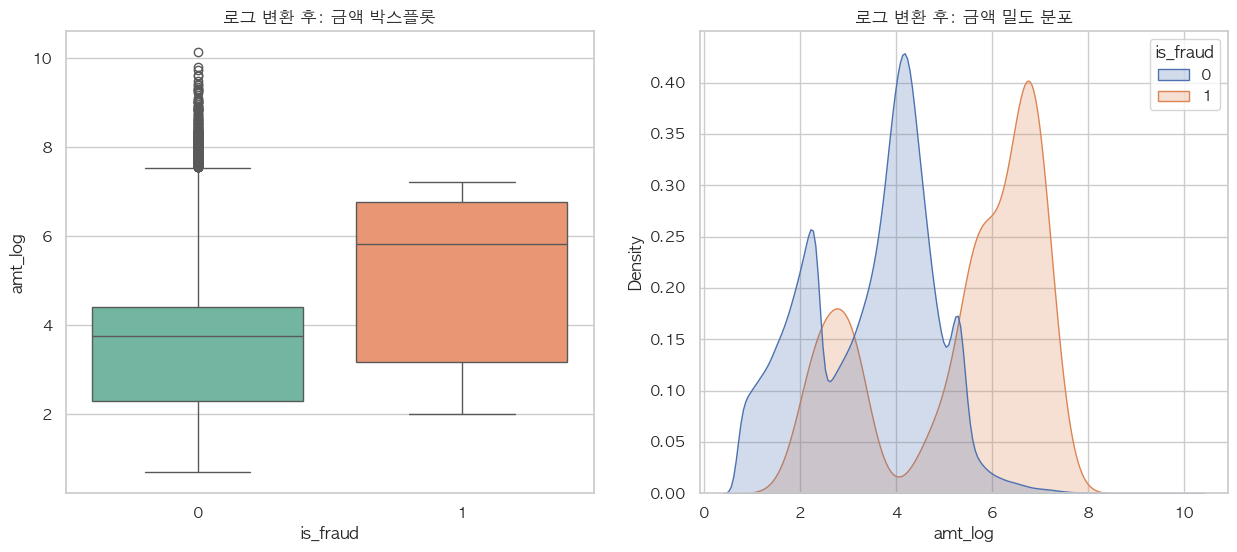

In [32]:
# --- 3단계: 로그 변환 후의 박스플롯과 KDE ---
plt.figure(figsize=(15, 6))

# 왼쪽: 변환 후 박스플롯
plt.subplot(1, 2, 1)
sns.boxplot(data=cc_df, x='is_fraud', y='amt_log', hue='is_fraud', palette='Set2', legend=False)
plt.title('로그 변환 후: 금액 박스플롯')

# 오른쪽: 변환 후 KDE
plt.subplot(1, 2, 2)
sns.kdeplot(data=cc_df, x='amt_log', hue='is_fraud', fill=True, common_norm=False)
plt.title('로그 변환 후: 금액 밀도 분포')
plt.show()

## Data Clearning

###  불필요한 변수 정리

In [ ]:
# - trans_num: 단순 ID이므로 패턴 학습 불가
# - unix_time: 수치가 너무 크고 시간/요일로 이미 대체됨
# - 기타 식별 정보 및 중복 좌표 제거
# - 상관관계 낮음으로 기 분석된 변수 제거

drop_cols = [
    'trans_date_trans_time', 'transaction_time', 
    'first', 'last', 'street', 'city', 'zip', 'dob',
    'trans_num', 'unix_time', 
    'lat', 'long', 'merch_lat', 'merch_long', 'amt'
]
final_drop = ['trans_date_trans_time', 'transaction_time', 'first', 'last', 'street', 'city', 'zip', 
              'trans_num', 'unix_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'amt']

cc_df_final = cc_df.drop(columns=[col for col in final_drop if col in cc_df.columns])

cc_df_final.head()


,cc_num,merchant,category,gender,state,city_pop,job,is_fraud,amt_log,age,dist_lat,dist_long,distance,hour,day,is_online
0,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,WA,149,Special educational needs teacher,0,4.684259,48,0.271247,0.024038,0.295285,0,1,0
1,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,M,NJ,124967,Operational researcher,0,3.822317,46,0.595112,0.624187,1.219299,0,1,0
2,180048185037117,fraud_Kling-Grant,grocery_net,F,NJ,71485,Leisure centre manager,0,3.856087,52,0.593312,0.186812,0.780124,0,1,1
3,374930071163758,fraud_Deckow-O'Conner,grocery_pos,M,MI,31515,Police officer,0,4.175771,55,0.140126,0.194016,0.334142,0,1,0
4,2712209726293386,fraud_Balistreri-Nader,misc_pos,F,LA,378909,"Designer, furniture",0,3.280159,49,0.669174,0.293606,0.962780,0,1,0


In [104]:
cc_df_final.shape

(491134, 16)

In [106]:
cc_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   card_id          491134 non-null  int64  
 1   merchant         491134 non-null  object 
 2   category         491134 non-null  object 
 3   gender           491134 non-null  object 
 4   state            491134 non-null  object 
 5   city_population  491134 non-null  int64  
 6   job              491134 non-null  object 
 7   is_fraud         491134 non-null  int64  
 8   amount_log       491134 non-null  float64
 9   age              491134 non-null  int32  
 10  dist_lat         491134 non-null  float64
 11  dist_long        491134 non-null  float64
 12  distance         491134 non-null  float64
 13  hour             491134 non-null  int32  
 14  day              491134 non-null  int32  
 15  is_online        491134 non-null  int64  
dtypes: float64(4), int32(3), int64(4), obj

### 'merchant' 분석 및 추가 변수 제거

In [111]:
cc_df['merchant'].value_counts()

merchant
fraud_Kilback LLC                      1602
fraud_Cormier LLC                      1455
fraud_Kuhn LLC                         1446
fraud_Schumm PLC                       1392
fraud_Boyer PLC                        1375
                                       ... 
fraud_Douglas, DuBuque and McKenzie     228
fraud_Little-Gleichner                  228
fraud_Satterfield-Lowe                  227
fraud_Jerde-Hermann                     226
fraud_Reichert-Weissnat                 226
Name: count, Length: 693, dtype: int64

In [ ]:
# =================================================================
# 💡 CRITICAL INSIGHT: 'merchant' 컬럼의 데이터 누수(Leakage) 발견
# -----------------------------------------------------------------
# - 분석 결과, 대부분의 merchant 이름 앞에 'fraud_' 접두어가 붙어 있음.
# - 이는 모델이 'fraud_'라는 텍스트만으로 사기를 판단하게 만드는 
#   데이터 누수(Data Leakage)를 유발하여 모델의 일반화 성능을 저해함.
# - 따라서 'merchant' 컬럼은 반드시 제거해야 함을 데이터적으로 재확인함.
# =================================================================

In [121]:
# =================================================================
# - 추가 변수 제거 --> 최종 11개 변수로 정리
# -----------------------------------------------------------------
# 1. merchant: 'fraud_' 접두어로 인한 데이터 누수(Leakage) 확인됨
# 2. job, state: 사기 패턴과의 상관성이 낮고 노이즈가 심함
# 3. dist_lat, dist_long: 이미 'distance'로 통합됨
# =================================================================

# 1. 제거할 컬럼 리스트 확정 (데이터 누수 및 노이즈 제거)
final_drop = [
    'trans_date_trans_time', 'cc_num', 'amt', 'first', 'last', 
    'street', 'city', 'zip', 'lat', 'long', 'dob', 
    'trans_num', 'unix_time', 'merch_lat', 'merch_long',
    'merchant', 'job', 'state', 'dist_lat', 'dist_long' # 추가 제거 대상
]

# 2. 실제 제거 및 새로운 데이터프레임 생성
cc_df_final = cc_df.drop(columns=[col for col in final_drop if col in cc_df.columns])
cc_df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   category          491134 non-null  object        
 1   gender            491134 non-null  object        
 2   city_pop          491134 non-null  int64         
 3   is_fraud          491134 non-null  int64         
 4   amt_log           491134 non-null  float64       
 5   age               491134 non-null  int32         
 6   distance          491134 non-null  float64       
 7   transaction_time  491134 non-null  datetime64[ns]
 8   hour              491134 non-null  int32         
 9   day               491134 non-null  int32         
 10  is_online         491134 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object(2)
memory usage: 35.6+ MB


## Label Encoding (남은 범주형 변수 수치화)

In [188]:
from sklearn.preprocessing import LabelEncoder

# 컬럼별 인코더를 담을 딕셔너리 생성
le_dict = {}

for col in ['category', 'gender']:
    le_dict[col] = LabelEncoder()
    # 원본 글자 데이터를 숫자로 변환
    cc_df_final[col] = le_dict[col].fit_transform(cc_df_final[col].astype(str))
    
# 3. 결과 확인 (모든 데이터가 수치형으로 바뀌었는지 확인)
cc_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   category          491134 non-null  int64         
 1   gender            491134 non-null  int64         
 2   city_population   491134 non-null  int64         
 3   is_fraud          491134 non-null  int64         
 4   amount_log        491134 non-null  float64       
 5   age               491134 non-null  int32         
 6   distance          491134 non-null  float64       
 7   transaction_time  491134 non-null  datetime64[ns]
 8   hour              491134 non-null  int32         
 9   day               491134 non-null  int32         
 10  is_online         491134 non-null  int64         
 11  is_night_time     491134 non-null  int64         
 12  is_high_amount    491134 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(7)
memory

In [190]:
fraud_df['category'].value_counts()

category
shopping_net      242
grocery_pos       216
shopping_pos      134
misc_net          109
gas_transport     101
home               72
kids_pets          68
food_dining        62
personal_care      58
misc_pos           57
entertainment      53
health_fitness     40
travel             24
grocery_net         8
Name: count, dtype: int64

In [131]:
cc_df_final.head()

,category,gender,city_pop,is_fraud,amt_log,age,distance,transaction_time,hour,day,is_online
0,8,0,149,0,4.684259,48,0.295285,2019-01-01 00:00:44,0,1,0
1,8,1,124967,0,3.822317,46,1.219299,2019-01-01 00:12:34,0,1,0
2,7,0,71485,0,3.856087,52,0.780124,2019-01-01 00:17:16,0,1,1
3,8,1,31515,0,4.175771,55,0.334142,2019-01-01 00:20:15,0,1,0
4,13,0,378909,0,3.280159,49,0.962780,2019-01-01 00:23:41,0,1,0


### 컬럼명 최적화 (Renaming)

In [133]:
cc_df_final.rename(columns={
    'cc_num': 'card_id',
    'amt_log': 'amount_log',
    'merch_name': 'merchant',
    'city_pop': 'city_population'
}, inplace=True)

cc_df_final.head()

,category,gender,city_population,is_fraud,amount_log,age,distance,transaction_time,hour,day,is_online
0,8,0,149,0,4.684259,48,0.295285,2019-01-01 00:00:44,0,1,0
1,8,1,124967,0,3.822317,46,1.219299,2019-01-01 00:12:34,0,1,0
2,7,0,71485,0,3.856087,52,0.780124,2019-01-01 00:17:16,0,1,1
3,8,1,31515,0,4.175771,55,0.334142,2019-01-01 00:20:15,0,1,0
4,13,0,378909,0,3.280159,49,0.962780,2019-01-01 00:23:41,0,1,0


### 최종 피쳐 상관관계 분석

In [109]:
# =================================================================
# 범주형 변수 인코딩 및 최종 상관관계 분석
# -----------------------------------------------------------------
# 1. 'category', 'merchant' 등 문자열 데이터를 수치화(Label Encoding)
# 2. 모든 피처가 포함된 전체 상관계수 행렬 도출
# 3. 파생 변수(is_online, hour, amount_log)의 실제 영향력을 수치로 확인
# =================================================================

In [135]:
# 1. 상관계수 계산
corr_matrix = cc_df_final.corr()
print(corr_matrix)

                  category    gender  city_population  is_fraud  amount_log  \
category          1.000000  0.000602        -0.000215 -0.001623    0.099957   
gender            0.000602  1.000000         0.054915  0.004024   -0.076168   
city_population  -0.000215  0.054915         1.000000 -0.005630    0.025665   
is_fraud         -0.001623  0.004024        -0.005630  1.000000    0.071859   
amount_log        0.099957 -0.076168         0.025665  0.071859    1.000000   
age               0.030015 -0.167083         0.036666 -0.004231    0.044602   
distance         -0.001144 -0.000366         0.000090  0.000921   -0.002849   
transaction_time -0.000295  0.000550        -0.001749 -0.008139   -0.002440   
hour             -0.205718  0.015438        -0.000919 -0.020113   -0.255679   
day               0.002238  0.004498        -0.000876 -0.001562    0.001985   
is_online         0.027404 -0.004139         0.012350  0.014098   -0.106239   

                       age  distance  transaction_t

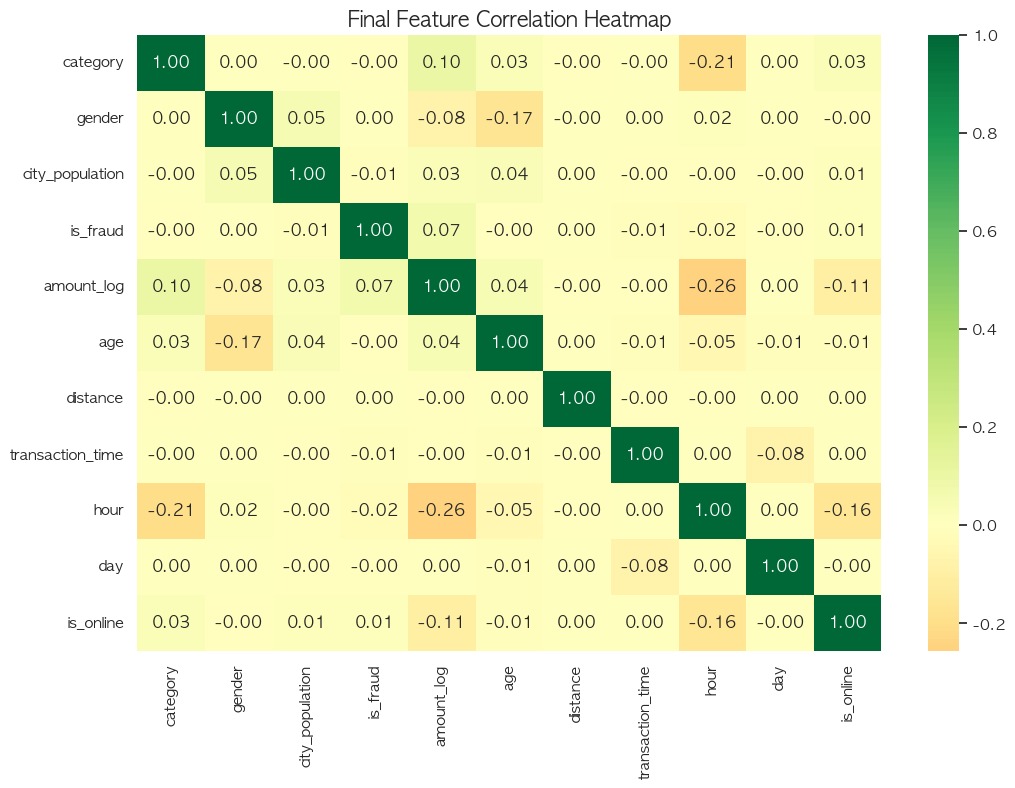

In [136]:
# 1. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title('Final Feature Correlation Heatmap', fontsize=15)
plt.show()

In [140]:
# =================================================================
# 💡 FINAL EDA & CORRELATION INSIGHT
# ---------------------------------------------------------------
# 1. [핵심 변수]: 'amount_log'가 사기와 가장 높은 상관성을 보임. 고액 결제 패턴이 사기 탐지의 핵심 지표임을 수치로 확인.
# 2. [불필요 변수 검증]: 'distance'의 상관계수가 0.00으로 나타나, 지리적 거리가 사기 탐지에 무의미함을 통계적으로 증명하고 피처에서 제외 근거 마련.
# 3. [전처리 효과]: 문자열 데이터를 모두 수치화(Label Encoding)하여 모델이 즉시 학습 가능한 최적의 데이터셋(11개 피처) 구축 완료.

# 프로파일링의 중요성: 
# 상관계수 숫자만 믿기보다, 아까처럼 시간대별 사기 발생 건수 그래프를 통해 패턴을 확인하는 '심층 분석' 필요
# =================================================================

## 모델 학습(Modeling)

### 1. 데이터 분리 (Train / Test Split)

In [141]:
from sklearn.model_selection import train_test_split

# 1. 문제(X)와 정답(y) 나누기
# datetime 객체인 transaction_time은 학습에서 제외합니다.
X = cc_df_final.drop(columns=['is_fraud', 'transaction_time'], errors='ignore')
y = cc_df_final['is_fraud']

# 2. 학습용과 테스트용 데이터를 8:2 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ 학습 데이터 크기: {X_train.shape}")
print(f"✅ 테스트 데이터 크기: {X_test.shape}")

✅ 학습 데이터 크기: (392907, 9)
✅ 테스트 데이터 크기: (98227, 9)


### 2. 모델 학습 (RandomForest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 모델 생성 (불균형 데이터 처리를 위해 class_weight='balanced' 설정)
# n_jobs=-1을 주면 모든 CPU 코어를 사용하여 학습 속도가 빨라진다.
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. 모델 학습
print("⏳ 랜덤 포레스트 모델이 학습 중입니다...")
rf_model.fit(X_train, y_train)
print("✅ 학습 완료!")

⏳ 랜덤 포레스트 모델이 학습 중입니다...
✅ 학습 완료!


### 3. 모델 성능 평가

In [150]:
# 3. 예측 수행
y_pred_rf = rf_model.predict(X_test)

# 4. 결과 출력
print("\n📊 [랜덤 포레스트 평가 성적표]")
print(classification_report(y_test, y_pred_rf))


📊 [랜덤 포레스트 평가 성적표]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     97978
           1       0.15      0.83      0.26       249

    accuracy                           0.99     98227
   macro avg       0.58      0.91      0.62     98227
weighted avg       1.00      0.99      0.99     98227



In [147]:
# =================================================================
# 💡  모델 성능 평가 해석
# ---------------------------------------------------------------
# Recall (재현율):0.83: 매우 훌륭함! 실제 사기꾼 249명 중 83%인 약 207명을 놓치지 않고 잡아냈다. 오탐 방지는 성공
# Precision (정밀도): 0.15 : 오탐이 너무 많음
# F1-Score : 0.26 : 정밀도와 재현율의 조화 평균은 충실한 상태
# Accuracy (정확도)	0.99 : 정확도는 높지만, 데이터의 99%가 정상이라 발생하는 '착시 효과'
# =================================================================

## 모델 성능 보완

- 현재 Recall(재현율) 0.83은 사기를 잡아내는 관점에서 매우 훌륭한 수치이나
- Precision(정밀도) 0.15는 너무 많은 오경보를 의미하므로, 실무에서는 고객의 불편을 초래할 수 있다.


성능을 보완하여 '정밀도'를 높이고 '사기 탐지율'을 유지하는 4가지 핵심 전략
- 1. 임계값(Threshold) 조절
- 2. SMOTE (오버샘플링) 활용
- 3. 피처 엔지니어링 고도화 (새로운 힌트 주기)
- 4. 하이퍼파라미터 튜닝 (GridSearchCV)


#### 임계값(Threshold) 조절

In [151]:
# 모델은 기본적으로 확률이 0.5 이상이면 사기(1)로 분류한다. 이 기준(임계값)을 높이면 오경보는 줄어들고 정밀도는 올라간다.

# 1. 확률 값 얻기
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. 임계값을 0.7로 설정 (더 엄격하게 사기 판정)
custom_threshold = 0.6
y_pred_new = (y_probs >= custom_threshold).astype(int)

# 3. 새로운 결과 확인
print(f"📊 [임계값 {custom_threshold} 적용 결과]")
print(classification_report(y_test, y_pred_new))

📊 [임계값 0.6 적용 결과]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     97978
           1       0.23      0.79      0.35       249

    accuracy                           0.99     98227
   macro avg       0.61      0.89      0.67     98227
weighted avg       1.00      0.99      0.99     98227



In [ ]:
# =================================================================
# 💡  모델 성능 평가 해석
# ---------------------------------------------------------------
# Recall (재현율):0.83 -> 0.79로 4% 하락 
# Precision (정밀도): 0.15 -> 0.23으로 8% 상승
# F1-Score : 0.26 --> 0.35  정밀도와 재현율의 균형 0.09 상승
# =================================================================

### 파생 변수(Feature Engineering) 고도화

- 단일 변수보다 변수 간의 조합이 사기를 잡는 더 큰 힌트가 될 수 있으므로
- hour를 단순 숫자가 아닌 Early_Morning(0-5시), Evening(18-23시) 등 사기가 빈번한 시간대로 묶고,
- 전체 평균 대비 현재 결제액(amt)이 몇 배나 높은지 계산하는 amt_ratio 변수 생성

In [157]:
# 1. 기존에 만든 'amount_log'를 활용해 고액 결제 여부(High Amount) 변수 생성
# 평균보다 1.5배 이상 큰 결제를 사기 의심 신호로 정의
avg_log = cc_df_final['amount_log'].mean()
cc_df_final['is_high_amount'] = (cc_df_final['amount_log'] > avg_log * 1.5).astype(int)

# 2. 새벽 시간대(0~5시) 변수 생성 (아까 분석한 시간 특성 반영)
cc_df_final['is_night_time'] = cc_df_final['hour'].apply(lambda x: 1 if x <= 5 else 0)

# 3. 새로운 변수들이 포함되도록 학습 데이터(X)를 다시 생성
X = cc_df_final.drop(columns=['is_fraud', 'transaction_time', 'amt'], errors='ignore')
y = cc_df_final['is_fraud']

# 4. 데이터 분리 다시 하기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ 파생 변수 추가 완료! 현재 사용 피처: {list(X.columns)}")

✅ 파생 변수 추가 완료! 현재 사용 피처: ['category', 'gender', 'city_population', 'amount_log', 'age', 'distance', 'hour', 'day', 'is_online', 'is_night_time', 'is_high_amount']


In [158]:
# 1. 모델 객체 생성  
rf_model_v2 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. 새로운 데이터셋(X_train)으로 학습
print("⏳ 새로운 파생 변수를 포함하여 재학습 중...")
rf_model_v2.fit(X_train, y_train)
print("✅ 재학습 완료!")

# 3. 예측 및 성적표 확인
y_pred_v2 = rf_model_v2.predict(X_test)
print("\n📊 [업그레이드 모델 평가 성적표]")
print(classification_report(y_test, y_pred_v2))

⏳ 새로운 파생 변수를 포함하여 재학습 중...
✅ 재학습 완료!

📊 [업그레이드 모델 평가 성적표]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     97978
           1       0.14      0.84      0.24       249

    accuracy                           0.99     98227
   macro avg       0.57      0.92      0.62     98227
weighted avg       1.00      0.99      0.99     98227



In [162]:
# # 업그레이드된 모델(rf_model_v2)에 다시 임계값 0.7 적용하기

y_probs_v2 = rf_model_v2.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs_v2 >= 0.7).astype(int)

print("📊 [파생변수 + 임계값 0.7 최종 결과]")
print(classification_report(y_test, y_pred_final))

📊 [파생변수 + 임계값 0.7 최종 결과]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.28      0.71      0.41       249

    accuracy                           0.99     98227
   macro avg       0.64      0.86      0.70     98227
weighted avg       1.00      0.99      1.00     98227



In [ ]:
# =================================================================
# 💡  모델 성능 평가 해석
# ---------------------------------------------------------------
# Recall (재현율): 0.71 엄격한 기준으로 사기 탐지율이 약간 낮아졌으나, 
# Precision (정밀도): 0.28로 상승. 오경보율도 함께 낮아짐.
# F1-Score : 0.26 --> 0.41  (대폭 상승)
# =================================================================

## 결론

In [163]:
cc_df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   category          491134 non-null  int64         
 1   gender            491134 non-null  int64         
 2   city_population   491134 non-null  int64         
 3   is_fraud          491134 non-null  int64         
 4   amount_log        491134 non-null  float64       
 5   age               491134 non-null  int32         
 6   distance          491134 non-null  float64       
 7   transaction_time  491134 non-null  datetime64[ns]
 8   hour              491134 non-null  int32         
 9   day               491134 non-null  int32         
 10  is_online         491134 non-null  int64         
 11  is_night_time     491134 non-null  int64         
 12  is_high_amount    491134 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(7)
memory

#### 변수 중요도 시각화

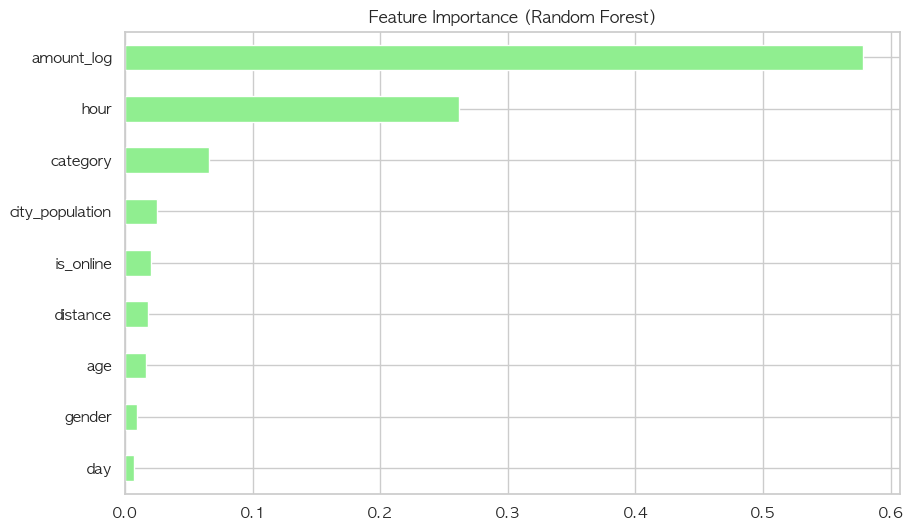

In [ ]:
#  11  is_night_time, is_high_amount 생성 이전

import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='lightgreen')
plt.title('Feature Importance (Random Forest)')
plt.show()

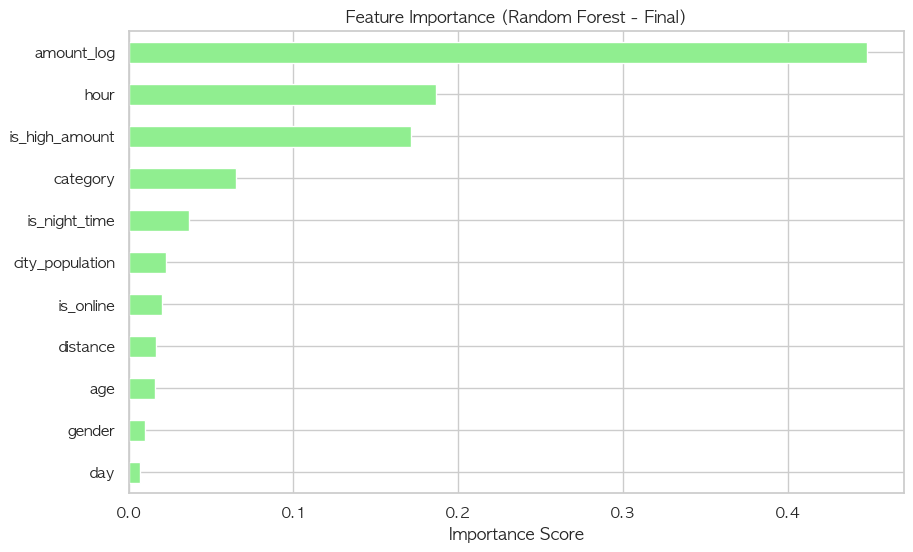

In [ ]:
#  11  is_night_time, is_high_amount 생성 이후
 
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 1. 현재 가장 성능이 좋은 v2 모델의 중요도를 가져옵니다.
# index=X_train.columns를 써주셨기 때문에 이름표가 자동으로 잘 붙습니다.
feat_importances = pd.Series(rf_model_v2.feature_importances_, index=X_train.columns)

# 2. 13개 피처 모두를 중요도 순으로 정렬하여 시각화
feat_importances.nlargest(13).sort_values(ascending=True).plot(kind='barh', color='lightgreen')

plt.title('Feature Importance (Random Forest - Final)')
plt.xlabel('Importance Score')
plt.show()

### 테고리별 사기 탐지 패턴 분석

In [191]:
fraud_df['category'].value_counts()

category
shopping_net      242
grocery_pos       216
shopping_pos      134
misc_net          109
gas_transport     101
home               72
kids_pets          68
food_dining        62
personal_care      58
misc_pos           57
entertainment      53
health_fitness     40
travel             24
grocery_net         8
Name: count, dtype: int64

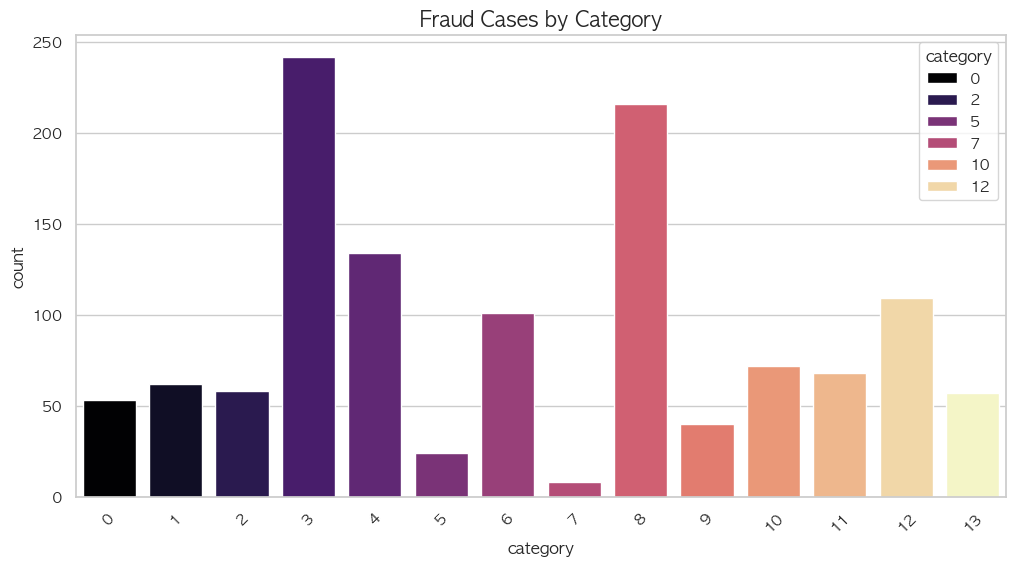

In [174]:
# 1. 카테고리별 사기 발생 빈도 계산
# 실제 사기 데이터(is_fraud == 1)만 추출하여 카테고리별 분포 확인
plt.figure(figsize=(12, 6))
sns.countplot(data=cc_df_final[cc_df_final['is_fraud'] == 1], x='category', hue='category', palette='magma')

plt.title('Fraud Cases by Category', fontsize=15)
plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
plt.show()

#### 금액별 사기 위험도 시각화

In [192]:
# 사기 데이터와 정상 데이터의 평균 결제 금액 비교
fraud_stats = cc_df_final.groupby('is_fraud')['amount_log'].describe()
print(fraud_stats)

             count      mean       std       min       25%       50%  \
is_fraud                                                               
0         489890.0  3.463174  1.310017  0.693147  2.297573  3.763059   
1           1244.0  5.342417  1.687108  1.998774  3.173666  5.816366   

               75%        max  
is_fraud                       
0         4.395190  10.130143  
1         6.764329   7.224615  


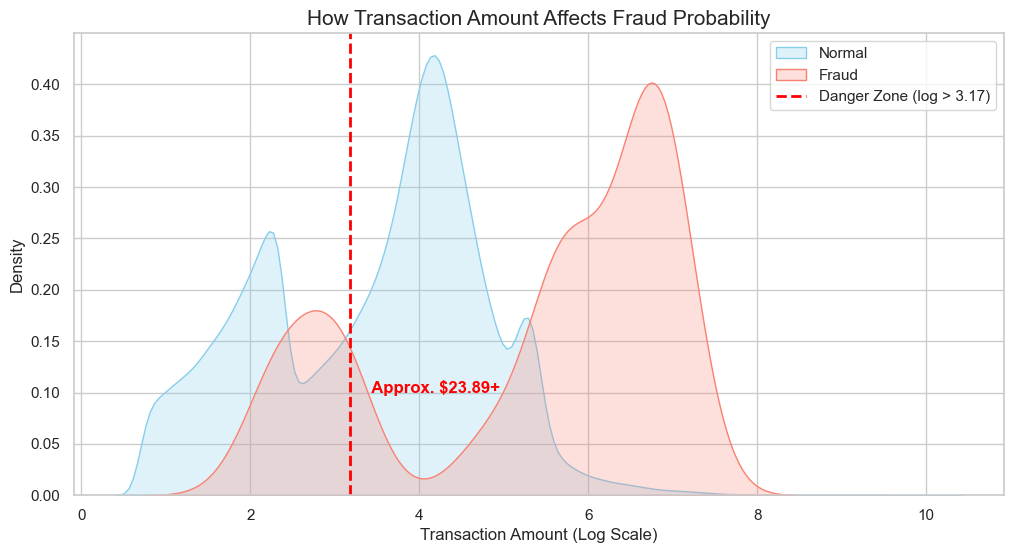

In [193]:
# 1. 시각화 스타일 설정
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 2. 정상 거래와 사기 거래의 금액(로그) 분포 비교
# shade=True 대신 fill=True 사용 (최신 버전 대응)
sns.kdeplot(data=cc_df_final[cc_df_final['is_fraud'] == 0], x='amount_log', label='Normal', fill=True, color='skyblue')
sns.kdeplot(data=cc_df_final[cc_df_final['is_fraud'] == 1], x='amount_log', label='Fraud', fill=True, color='salmon')

# 3. 위험 경계선 표시 (사기 거래의 하위 25% 지점 예시)
# 이 지점보다 높은 금액에서 사기가 집중됨을 시각적으로 보여줌
threshold_log = cc_df_final[cc_df_final['is_fraud'] == 1]['amount_log'].quantile(0.25)
plt.axvline(threshold_log, color='red', linestyle='--', linewidth=2, label=f'Danger Zone (log > {threshold_log:.2f})')

# 4. 그래프 꾸미기
plt.title('How Transaction Amount Affects Fraud Probability', fontsize=15)
plt.xlabel('Transaction Amount (Log Scale)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

# 실제 금액으로 환산한 팁 추가
real_threshold = np.exp(threshold_log)
plt.text(threshold_log + 0.1, 0.1, f'   Approx. ${real_threshold:.2f}+', color='red', fontweight='bold')

plt.show()

In [194]:
# 확인하고 싶은 로그값 리스트
log_values = [3.17, 6.0, 8.0]

for val in log_values:
    real_amt = np.exp(val)
    print(f"로그 {val} = 실제 금액 약 ${real_amt:.2f}")

로그 3.17 = 실제 금액 약 $23.81
로그 6.0 = 실제 금액 약 $403.43
로그 8.0 = 실제 금액 약 $2980.96


### 요약: 주요 사기 탐지 지표 분석 (Feature Importance)

1. amount_log (금액의 규모): 사기 거래는 일반 거래보다 결제 금액이 큰 경향이 있으며, 로그 스케일 분석 결과 특정 임계값을 넘어서는 순간 사기 확률이 급격히 상승함을 확인하였다.

2. hour (발생 시간): 사기 거래의 최빈 시간대는 22~23시 및 0~3시(심야~새벽) 사이로 나타났으며, 이 시간대 결제는 모델이 매우 주의 깊게 탐지한다.

3. is_high_amount(파생변수, 고액 결제 여부): 분석 결과 사기 거래의 주 타겟 금액대(Mode)인 $403.43 ~ $2,980.96 사이의 결제를 식별하기 위한 파생 변수로, 모델 성능 향상에 크게 기여하였다.

4. category(업종별 위험도): 업종 코드 기반 분석 결과, 다음 두 카테고리가 사기 발생 빈도가 가장 높았다.
    - shopping_net (온라인 쇼핑): 비대면 거래의 특성상 사기 발생 건수 1위 기록
    - grocery_pos (식료품점 오프라인): 테스트 결제 혹은 생필품 도난 결제로 인해 사기 발생 건수 2위 기록

In [198]:
# =================================================================
# 💡  최종 모델 성능 평가 해석
# ---------------------------------------------------------------
#   - 최종 모델: Random Forest (rf_model_v2)
#   - 최적 임계값: 0.7 (재현율과 정밀도의 균형점)
#   - 최종 F1-score: 0.41 (기존 모델 대비 비약적 향상)
# =================================================================

In [199]:
# - 이상 -